# Comparativa final — 3 modelos

En este notebook evaluamos los 3 modelos entrenados sobre el conjunto de test
y seleccionamos el mejor.

| Exp | Modelo | Notebook |
|-----|--------|----------|
| 0 | LogReg + TF-IDF (baseline) | 3 + 4 |
| 1 | LogReg + TF-IDF + features manuales | 5 + 6 |
| 2 | XGBoost + TF-IDF + features manuales + Grid Search | 7 |

Contenido:
1. Carga de modelos y datos
2. Predicciones sobre test
3. Tabla comparativa de métricas
4. Gráfico comparativo
5. Matrices de confusión
6. Curvas ROC
7. Análisis de errores del mejor modelo
8. Selección del mejor modelo
9. Registro en MLflow

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Carga de modelos y datos

In [14]:
import pandas as pd
import numpy as np
import joblib
from functions import (
    crear_tfidf, crear_features_manuales, combinar_features,
    mostrar_matriz_confusion,
)

# Datos
train_df = pd.read_csv("data/processed/train.csv")
val_df = pd.read_csv("data/processed/validation.csv")
test_df = pd.read_csv("data/processed/test.csv")

X_train = train_df["text_final"]
X_val = val_df["text_final"]
X_test = test_df["text_final"]
y_test = test_df["etiqueta"]

# TF-IDF
tfidf = joblib.load("model/tfidf_vectorizer.joblib")
X_test_tfidf = tfidf.transform(X_test)

# Features manuales
feat_test = crear_features_manuales(X_test)
X_test_combined = combinar_features(X_test_tfidf, feat_test)

# Modelos (cada uno con su nombre único)
modelo_baseline = joblib.load("model/modelo_baseline.joblib")       # Exp 0: solo TF-IDF (3811 feat.)
modelo_v2 = joblib.load("model/modelo_logreg_v2.joblib")            # Exp 1: TF-IDF + manuales (3817 feat.)
modelo_xgb = joblib.load("model/modelo_xgboost.joblib")             # Exp 2: XGBoost (3817 feat.)
le = joblib.load("model/label_encoder.joblib")

clases = sorted(y_test.unique())
print(f"Test: {len(X_test)} muestras")
print(f"Clases: {clases}")
print(f"3 modelos cargados correctamente.")

Test: 45 muestras
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']
3 modelos cargados correctamente.


## 2. Predicciones sobre test

In [15]:
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Exp 0: Baseline (LogReg + TF-IDF solo → 3811 features) ---
y_pred_baseline = modelo_baseline.predict(X_test_tfidf)
y_proba_baseline = modelo_baseline.predict_proba(X_test_tfidf)

# --- Exp 1: LogReg + TF-IDF + features manuales (3817 features) ---
y_pred_v2 = modelo_v2.predict(X_test_combined)
y_proba_v2 = modelo_v2.predict_proba(X_test_combined)

# --- Exp 2: XGBoost (3817 features) ---
y_pred_xgb_enc = modelo_xgb.predict(X_test_combined)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)
y_proba_xgb = modelo_xgb.predict_proba(X_test_combined)

print("Predicciones generadas para los 3 modelos.")

Predicciones generadas para los 3 modelos.


## 3. Tabla comparativa de métricas

In [16]:
def calcular_metricas(y_true, y_pred, y_proba, clases):
    """Calcula métricas para un modelo."""
    report = classification_report(y_true, y_pred, output_dict=True)
    y_bin = label_binarize(y_true, classes=clases)

    roc_aucs = []
    for i, clase in enumerate(clases):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_aucs.append(auc(fpr, tpr))

    return {
        "F1-macro": report["macro avg"]["f1-score"],
        "Accuracy": report["accuracy"],
        "Precision macro": report["macro avg"]["precision"],
        "Recall macro": report["macro avg"]["recall"],
        "ROC AUC macro": np.mean(roc_aucs),
    }


resultados = {}

resultados["Exp 0: LogReg + TF-IDF"] = calcular_metricas(
    y_test, y_pred_baseline, y_proba_baseline, clases
)

resultados["Exp 1: LogReg + TF-IDF + feat."] = calcular_metricas(
    y_test, y_pred_v2, y_proba_v2, clases
)

resultados["Exp 2: XGBoost + GS + k-fold"] = calcular_metricas(
    y_test, y_pred_xgb, y_proba_xgb, clases
)

df_comparativa = pd.DataFrame(resultados).T
print("=== COMPARATIVA EN TEST ===\n")
print(df_comparativa.round(4).to_string())

=== COMPARATIVA EN TEST ===

                                F1-macro  Accuracy  Precision macro  Recall macro  ROC AUC macro
Exp 0: LogReg + TF-IDF            0.9530    0.9556           0.9629        0.9500         0.9968
Exp 1: LogReg + TF-IDF + feat.    0.7330    0.7333           0.7361        0.7439         0.9004
Exp 2: XGBoost + GS + k-fold      0.7707    0.7778           0.8100        0.7923         0.9027


## 4. Gráfico comparativo

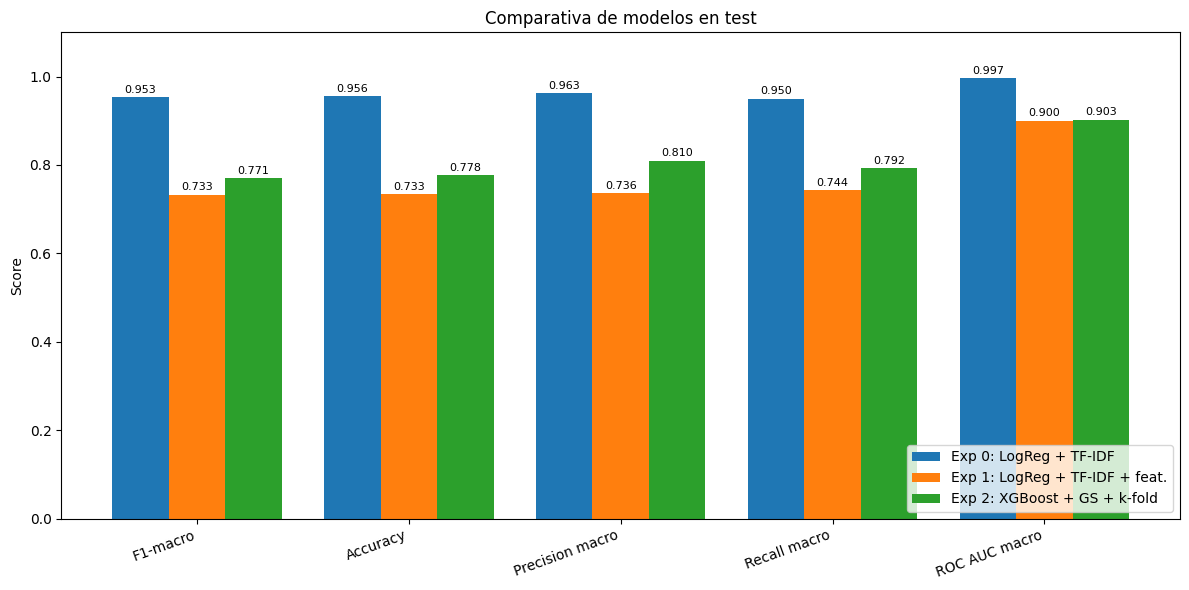

In [17]:
import matplotlib.pyplot as plt

fig_bar, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_comparativa.columns))
width = 0.8 / len(df_comparativa)

for i, (nombre, metricas) in enumerate(df_comparativa.iterrows()):
    offset = (i - len(df_comparativa) / 2 + 0.5) * width
    bars = ax.bar(x + offset, metricas.values, width, label=nombre)
    for bar, val in zip(bars, metricas.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Score")
ax.set_title("Comparativa de modelos en test")
ax.set_xticks(x)
ax.set_xticklabels(df_comparativa.columns, rotation=20, ha="right")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 5. Matrices de confusión

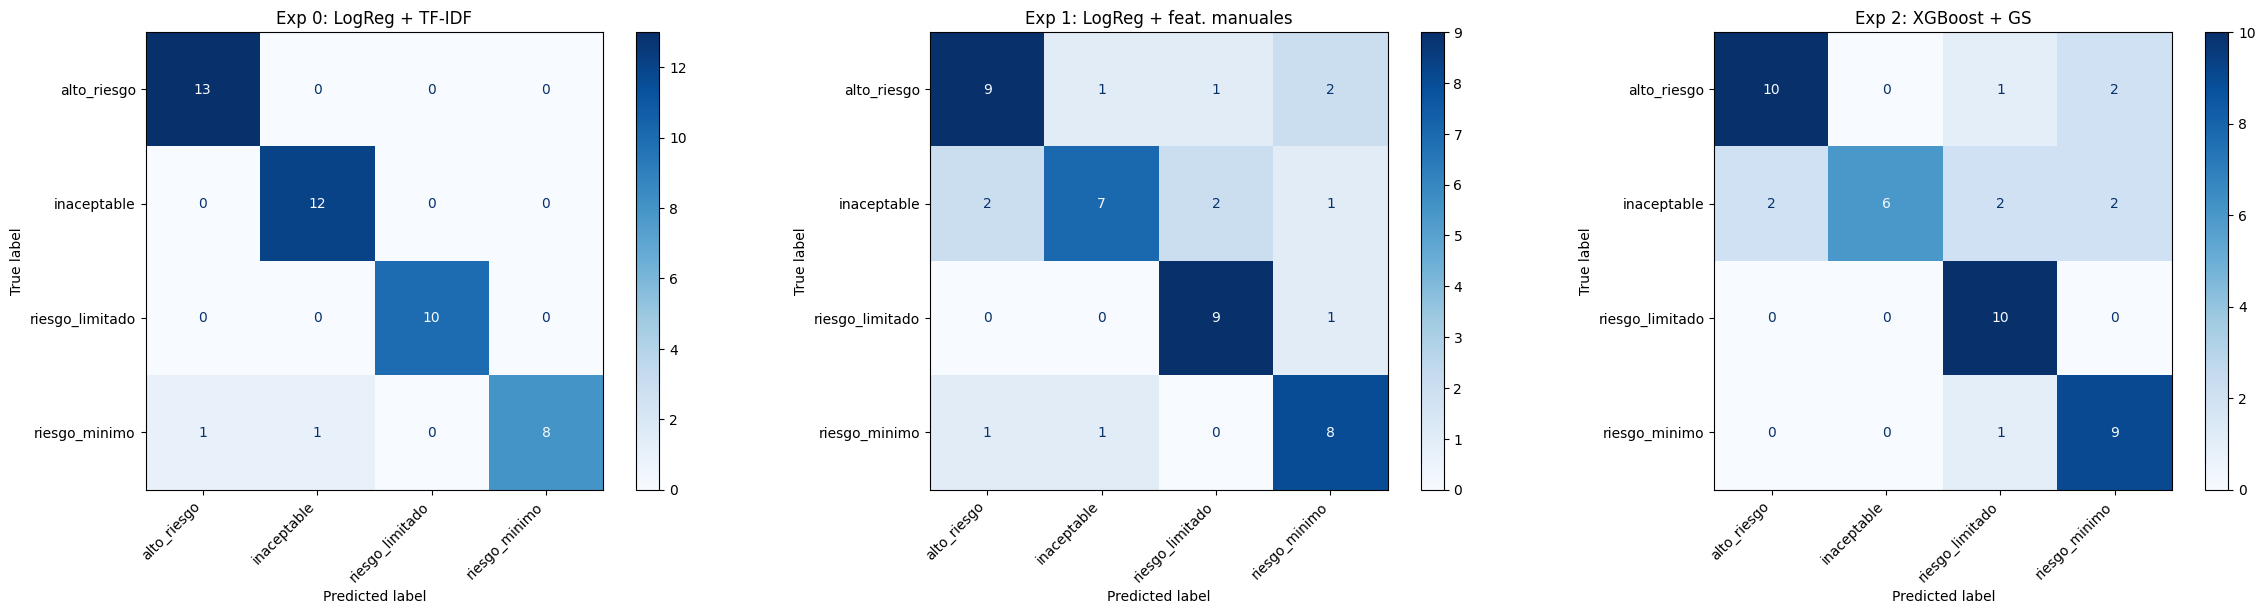

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modelos_pred = {
    "Exp 0: LogReg + TF-IDF": y_pred_baseline,
    "Exp 1: LogReg + feat. manuales": y_pred_v2,
    "Exp 2: XGBoost + GS": y_pred_xgb,
}

fig_cms, axes = plt.subplots(1, len(modelos_pred), figsize=(8 * len(modelos_pred), 6))

for ax, (nombre, y_pred) in zip(axes, modelos_pred.items()):
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(nombre)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 6. Curvas ROC

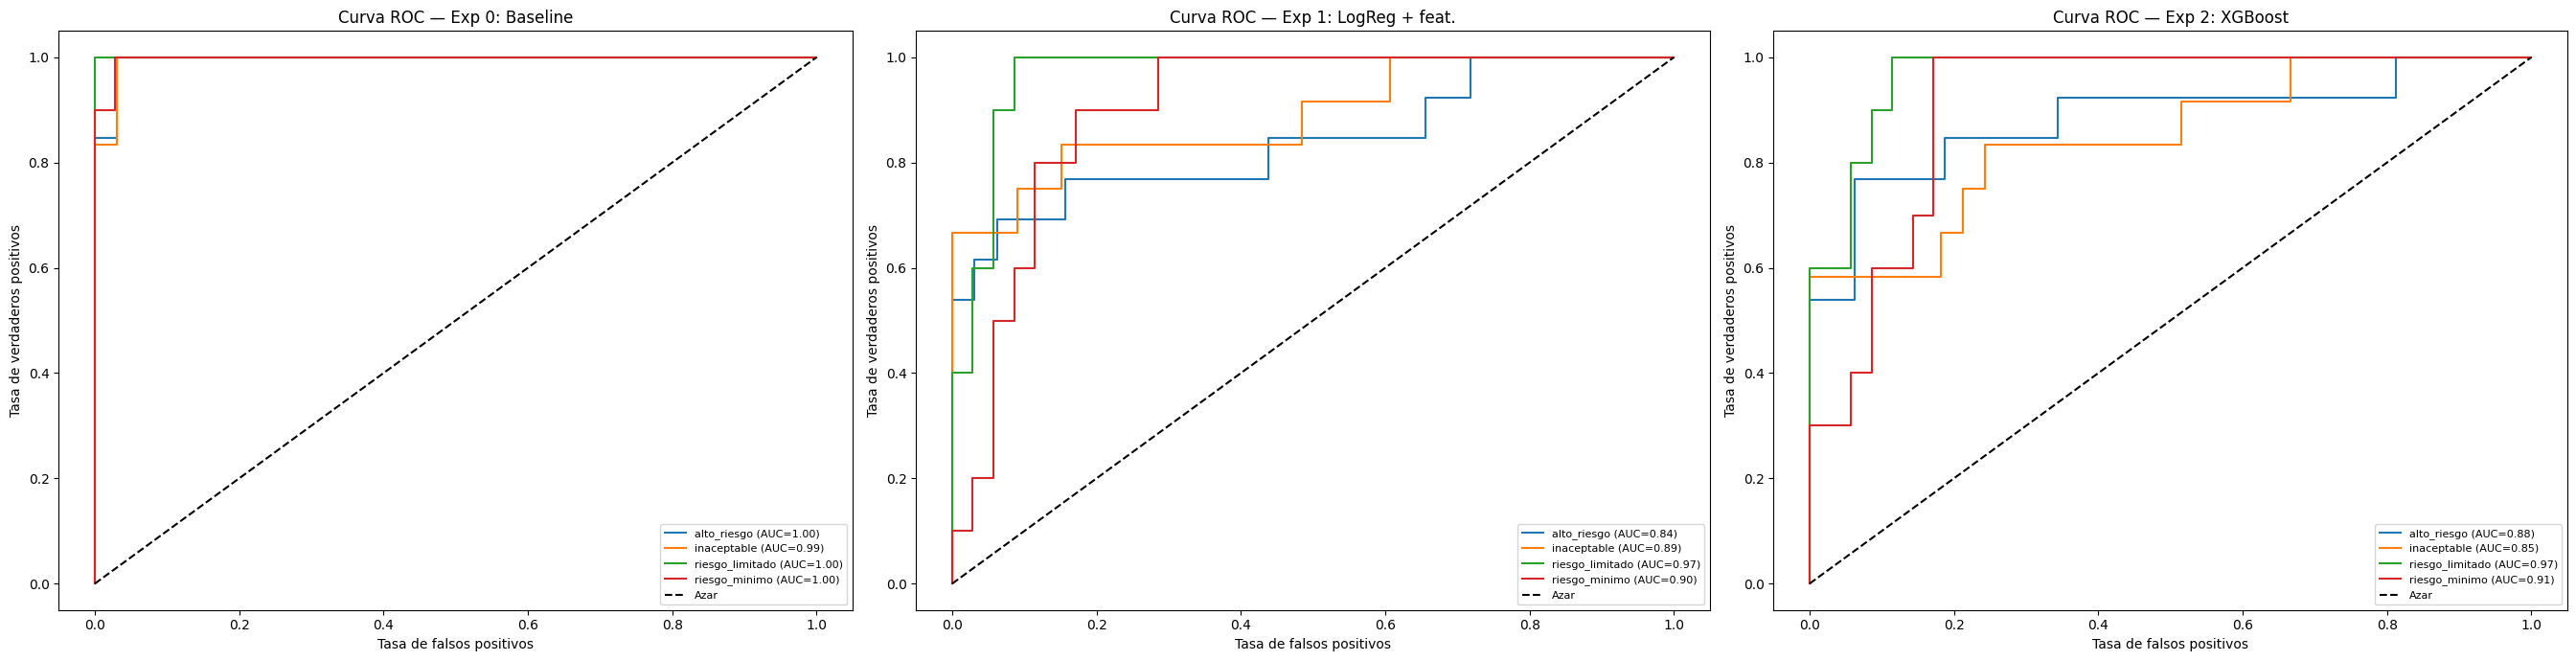

In [19]:
modelos_proba = {
    "Exp 0: Baseline": y_proba_baseline,
    "Exp 1: LogReg + feat.": y_proba_v2,
    "Exp 2: XGBoost": y_proba_xgb,
}

y_test_bin = label_binarize(y_test, classes=clases)

fig_roc, axes = plt.subplots(1, len(modelos_proba), figsize=(9 * len(modelos_proba), 7))

for ax, (nombre, y_proba) in zip(axes, modelos_proba.items()):
    for i, clase in enumerate(clases):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{clase} (AUC={roc_auc_val:.2f})")

    ax.plot([0, 1], [0, 1], "k--", label="Azar")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.set_title(f"Curva ROC — {nombre}")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 7. Análisis de errores del mejor modelo

In [20]:
# Seleccionar el mejor modelo según F1-macro
mejor_nombre = df_comparativa["F1-macro"].idxmax()
print(f"Mejor modelo: {mejor_nombre} (F1-macro: {df_comparativa.loc[mejor_nombre, 'F1-macro']:.4f})\n")

# Usar las predicciones del mejor modelo
mejor_pred = modelos_pred[mejor_nombre] if mejor_nombre in modelos_pred else y_pred_baseline

df_errores = pd.DataFrame({
    "texto": X_test.values,
    "etiqueta_real": y_test.values,
    "etiqueta_predicha": mejor_pred,
})
df_errores = df_errores[df_errores["etiqueta_real"] != df_errores["etiqueta_predicha"]]

if df_errores.empty:
    print("No hay errores de clasificación en el conjunto de test.")
else:
    print(f"Total de errores: {len(df_errores)} de {len(y_test)} "
          f"({len(df_errores)/len(y_test)*100:.1f}%)\n")
    print("Confusiones más frecuentes:")
    confusiones = df_errores.groupby(
        ["etiqueta_real", "etiqueta_predicha"]
    ).size().sort_values(ascending=False)
    print(confusiones)
    print("\nEjemplos mal clasificados:")
    for _, row in df_errores.iterrows():
        print(f"  Real: {row['etiqueta_real']} | Predicho: {row['etiqueta_predicha']}")
        print(f"  Texto: {row['texto'][:120]}...")
        print()

Mejor modelo: Exp 0: LogReg + TF-IDF (F1-macro: 0.9530)

Total de errores: 2 de 45 (4.4%)

Confusiones más frecuentes:
etiqueta_real  etiqueta_predicha
riesgo_minimo  alto_riesgo          1
               inaceptable          1
dtype: int64

Ejemplos mal clasificados:
  Real: riesgo_minimo | Predicho: inaceptable
  Texto: sistema reconocimiento imagen satelital monitorizar cultivo agrícola detectar zona afectado plaga sequía orientar inspec...

  Real: riesgo_minimo | Predicho: alto_riesgo
  Texto: algoritmo detección spam correos phishing filtrar automáticamente carpeta deseado usuario posibilidad revisión...



## 8. Selección del mejor modelo

In [21]:
print("=== RESUMEN FINAL ===\n")
print(df_comparativa.round(4).to_string())
print(f"\nModelo seleccionado: {mejor_nombre}")
print(f"Justificación: Mayor F1-macro en test ({df_comparativa.loc[mejor_nombre, 'F1-macro']:.4f})")
print(f"\nNota: F1-macro es la métrica principal porque trata todas las clases por igual,")
print(f"lo cual es importante en un dataset con clases ligeramente desbalanceadas.")

=== RESUMEN FINAL ===

                                F1-macro  Accuracy  Precision macro  Recall macro  ROC AUC macro
Exp 0: LogReg + TF-IDF            0.9530    0.9556           0.9629        0.9500         0.9968
Exp 1: LogReg + TF-IDF + feat.    0.7330    0.7333           0.7361        0.7439         0.9004
Exp 2: XGBoost + GS + k-fold      0.7707    0.7778           0.8100        0.7923         0.9027

Modelo seleccionado: Exp 0: LogReg + TF-IDF
Justificación: Mayor F1-macro en test (0.9530)

Nota: F1-macro es la métrica principal porque trata todas las clases por igual,
lo cual es importante en un dataset con clases ligeramente desbalanceadas.


## 9. Registro en MLflow

In [ ]:
import os
os.environ["MLFLOW_TRACKING_INSECURE_TLS"] = "true"
import mlflow
from functions import MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name="comparativa_final"):
    # Métricas de cada modelo
    for nombre, metricas in resultados.items():
        tag = nombre.split(":")[0].strip().replace(" ", "_").lower()
        for metrica, valor in metricas.items():
            mlflow.log_metric(f"{tag}_test_{metrica.lower().replace(' ', '_')}", valor)

    # Modelo seleccionado
    mlflow.log_param("mejor_modelo", mejor_nombre)
    mlflow.log_param("criterio_seleccion", "F1-macro")

    # Guardar gráficos
    fig_bar.savefig("model/comparativa_barras.png", dpi=150, bbox_inches="tight")
    mlflow.log_artifact("model/comparativa_barras.png")

    fig_cms.savefig("model/matrices_confusion_comparativa.png", dpi=150, bbox_inches="tight")
    mlflow.log_artifact("model/matrices_confusion_comparativa.png")

    fig_roc.savefig("model/curvas_roc_comparativa.png", dpi=150, bbox_inches="tight")
    mlflow.log_artifact("model/curvas_roc_comparativa.png")

    print(f"Comparativa final registrada en MLflow")
    print(f"  Mejor modelo: {mejor_nombre}")
    print(f"  Run ID: {mlflow.active_run().info.run_id}")